In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#               row,col,size
y = np.linspace(-1,1,30)
x = np.linspace(-1,1,30)
x,y = np.meshgrid(x,y)

# Horizontal stretches

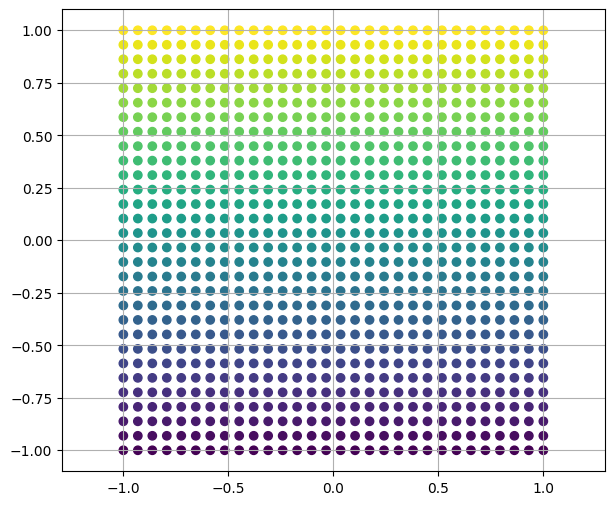

In [4]:
fig, ax = plt.subplots(figsize=(7,6))

ax.grid()
ax.scatter(x,y, c=y)

ax.axis("equal")

plt.show()

# vertical stretches

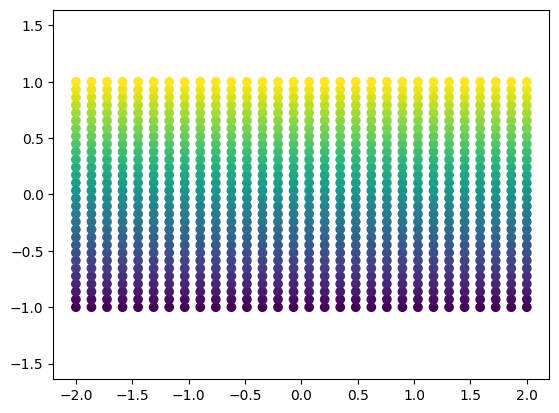

In [5]:
# streaching the axes

x1 = 2*x
y1 = 1*y
plt.scatter(x1,y1, c=y)
plt.axis('equal')
plt.show()

# [ cosθ -sinθ 
  #   sinθ cosθ]
    

In [90]:
x = np.linspace(-1, 1, 30)
y = np.linspace(-1, 1, 30)
x,y = np.meshgrid(x,y)

X = np.stack([x.ravel(), y.ravel()]) # X = [x, y]^T

theta = np.pi/4
# shrinking factor 
s = 0.5

A = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

# Rotation + shrinking of A
A = s * A

# transformed A
AX = A @ X

x_t = AX[0].reshape(x.shape)
y_t = AX[1].reshape(y.shape)

# Simplified version

# A = np.zeros((2,2))
# A[0,0] = np.cos(theta)
# A[0,1] = -np.sin(theta)
# A[1,0] = np.sin(theta)
# A[1,1] = np.cos(theta)

# x_t = A[0,0]*x + A[0,1]*y
# y_t = A[1,0]*x + A[1,1]*y

print(A)

[[ 0.35355339 -0.35355339]
 [ 0.35355339  0.35355339]]


# Rotation

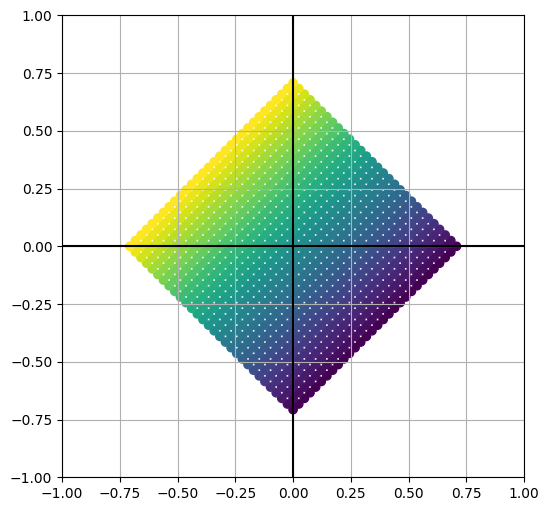

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

# axes
ax.axhline(0, color='k')
ax.axvline(0, color='k')

# figure 
ax.grid()
ax.scatter(x_t, y_t, c=y)

# coordinates axes limits
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

ax.set_aspect('equal')

plt.show()

# Determinant in a 2D co-oridinate system

In [92]:
A = np.array([[2,3], [-2,3]])

det = np.linalg.det(A)
print(det)

print(A*det)
new_A =  A * det

origin = np.zeros(A.shape)

12.0
[[ 24.  36.]
 [-24.  36.]]


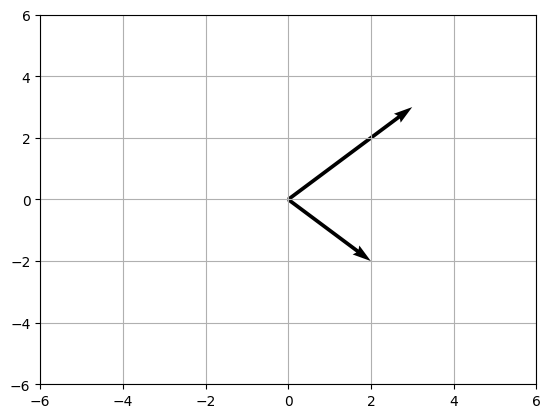

In [95]:
plt.quiver(*origin, *A, angles='xy', scale_units='xy', scale=1)

plt.grid()
plt.xlim(-6,6)
plt.ylim(-6,6)

plt.show()

If determinant is negative then order of i and j will not be preserve.


In [11]:
m = np.array(([2,3], [3,1]))
np.linalg.det(m)


np.float64(-7.000000000000001)

# Determinant in a 3D co-oridinate system



In [12]:
A = np.array([[3,3,0],[3,3,3],[3,0,3]])  #unit cube
origin = np.zeros(A.shape) 


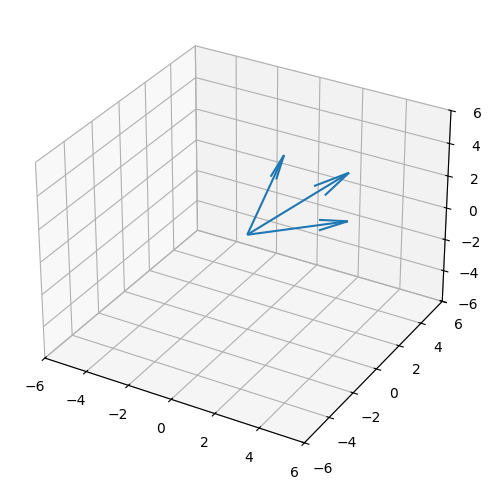

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,6))

ax = fig.add_subplot(projection='3d')


ax.quiver(*origin, *A) # -> parallelepiped

ax.grid()
ax.set_xlim3d(-6,6)
ax.set_ylim3d(-6,6)
ax.set_zlim3d(-6,6)

plt.show()

# Transformation view

# (AB)x=A(Bx)

In [96]:
A = np.array([[2,4],[-2,5]])
B = np.array([[1,9],[4,2]])
x = np.array([3,1])
r1 = (A@B) * x
r2 = A @(B*x)

print(np.allclose(r1, r2))

True


# Reflection matrix
Reflection matrix that reflects/flips the vectors across a line or plane.

For intuition

reflects an image on the mirror ( mirror -> line (2D) or (nD))

In [ ]:
M = np.eye(2, dtype=int)
ref = -1 * M[:, 1] + M[:, 0]
ref = np.diag(ref)

origin = np.zeros(M.shape)

array([[ 1,  0],
       [ 0, -1]])

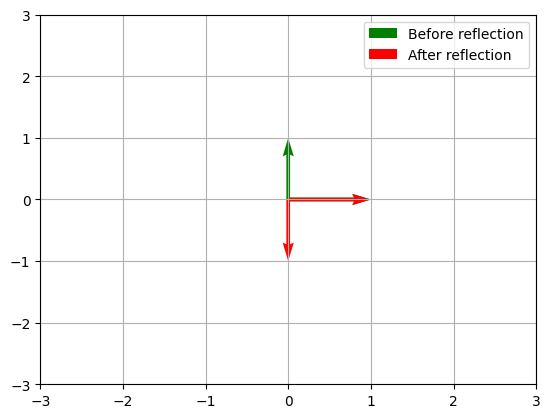

In [ ]:
plt.quiver(*origin, *M, color='g', angles='xy', scale_units='xy', scale=1, label='Before reflection')
plt.quiver(*origin, *ref, color='r', angles='xy', scale_units='xy', scale=1, label='After reflection')


plt.grid()
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.legend()

plt.show()

# Permutation matrix
Permutation matrix is obtained rearraning the rows of an identity matrix.

In [17]:
#  Identity matrix
v = np.zeros((3,3), dtype=int)
v[[0,1,2], [0,1,2]] = 1
print(v)

# Permutation matrix
w = np.zeros((3,3), dtype=int)
w[[0,1,2],[2,1,0]] = 1
print(w)

[[1 0 0]
 [0 1 0]
 [0 0 1]]
[[0 0 1]
 [0 1 0]
 [1 0 0]]


In [18]:
a = np.array([[4,3],[2,3]])
print(np.sqrt(np.sum(np.diff(a, axis=0)**2)))

x = np.array([3,1])
y = np.array([4,2])
print(np.sqrt(np.sum((x-y)**2)))
np.linalg.norm(x-y)



2.0
1.4142135623730951


np.float64(1.4142135623730951)

In [19]:
a = np.zeros((3,3))
b = np.ones((3,3))
# a[[0,1,2], ]
b.diagonal()


array([1., 1., 1.])

In [ ]:
V = np.array([
    [3,4,1],
    [1,3,4],
    [5,2,4]
])

W = np.array([
    [4,1,4],
    [5,3,3],
    [2,6,2]
])

# Linear Mapping phi: V -> W
# A linear map can be represented by transformation matrix A such that: AV = W => A = W V^-1

# Extracting vectors from V
v1 = V[:, 0]
v2 = V[:, 1]
v3 = V[:, 2]

# Extracting vectors from W
w1 = W[:, 0]
w2 = W[:, 1]
w3 = W[:, 2]

# Linear transformation A = W V^-1
A = W @ np.linalg.inv(V)

# Verify:  AV = W
AV = A @ V

# Outputs
print(f"Transformation matrix A =\n {A}")
print(f"Verfiy AV =\n {AV}")
print(np.allclose(W, AV))

Transformation matrix A =
 [[-0.31746032  0.11111111  0.96825397]
 [ 0.46031746 -0.11111111  0.74603175]
 [ 1.23809524  0.66666667 -0.47619048]]
Verfiy AV =
 [[4. 1. 4.]
 [5. 3. 3.]
 [2. 6. 2.]]
True


In [ ]:
# Linear Mapping phi: V -> W

A = np.array([
    [1,4,2],
    [5,2,5],
    [2,5,9]
])

# x E V 
x = np.array([7,5,1])
# y E W
y = np.array([4,2,5])

# Vector space
# Addition
left = A @ (x+y)
right = A @ x + A @ y
print(np.allclose(left, right))

# Scalar multiplication
lam = 3
left = A @ (lam * x)
right = lam * (A @ x)
print(np.allclose(left, right))

# def phi(x):
#     return A @ x

# # Vector space
# # additivity
# left = phi(x + y)
# right = phi(x) + phi(y)

# # check
# print(np.allclose(left, right))

# # homomogenity(scalar multiplication)
# lam = np.random.randint(1,9)

# left = phi(lam * x)
# right = lam * phi(x)
# print(np.allclose(left, right))


True
True
